# Ernesto — ML Training Smoke Test

Trains a binary classifier (plaintiff_win vs not) on the **matched** dataset of cases that have both features (X) and labels (y).

**Current state:** 126 matched rows, ~93 with non-null outcome. Too small for a real model — this is a pipeline smoke test.

## What this notebook does
1. **Build dataset** — joins features cache + labels into a single training table
2. **EDA** — outcome distribution, feature missingness
3. **Build X/y** — drops nulls, converts to numeric matrix
4. **Train + evaluate** — GradientBoostingClassifier with train/test split
5. **Visualize** — ROC curve + top features
6. **MLflow tracking** — logs run params, metrics, model, and artifacts so future runs are reproducible and comparable

In [73]:
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT      = Path('..').resolve()
FEATURES_CACHE = REPO_ROOT / 'features_cache'
LABELS_FILE    = REPO_ROOT / 'labels.json'
DATASET_CSV    = REPO_ROOT / 'dataset.csv'
DATASET_JSON   = REPO_ROOT / 'dataset.json'

## Build dataset (join features + labels)

Reads each cached feature file from `features_cache/`, joins it with the matching label
from `labels.json` on `case_number`, and writes `dataset.csv` + `dataset.json`.

In [74]:
features = {}
for f in os.listdir(FEATURES_CACHE):
    with open(FEATURES_CACHE / f) as fp:
        d = json.load(fp)
    if d.get('case_number'):
        features[d['case_number']] = d

with open(LABELS_FILE) as f:
    labels = json.load(f)

matched = sorted(set(features) & set(labels))
print(f'Features: {len(features)}  Labels: {len(labels)}  Matched: {len(matched)}')

rows = []
for cn in matched:
    feat, lbl = features[cn], labels[cn]
    row = {'case_number': cn}
    for k, v in feat.items():
        if k != 'case_number':
            row[f'feat_{k}'] = v
    for k in ['outcome', 'amount_awarded_principal', 'amount_awarded_costs',
              'amount_awarded_interest', 'defendant_appeared',
              'has_attorney_plaintiff', 'has_attorney_defendant']:
        row[f'label_{k}'] = lbl.get(k)
    parts = [lbl.get(k) for k in ['amount_awarded_principal','amount_awarded_costs','amount_awarded_interest']]
    row['label_total_awarded'] = sum(p or 0 for p in parts) if any(p is not None for p in parts) else None
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(DATASET_CSV, index=False)
DATASET_JSON.write_text(json.dumps(rows, indent=2, default=str))

print(f'\nWrote {DATASET_CSV.name} and {DATASET_JSON.name}')
print(f'Rows: {len(df)}  Columns: {df.shape[1]}')
df.head()

Features: 219  Labels: 940  Matched: 126

Wrote dataset.csv and dataset.json
Rows: 126  Columns: 58


,case_number,feat_feature_version,feat_user_is_plaintiff,feat_claim_category,feat_monetary_amount_claimed,feat_user_has_attorney,feat_opposing_party_has_attorney,feat_opposing_party_filed_response_documents,feat_counterclaim_present,feat_contract_present,...,feat_text_length,feat_document_count,label_outcome,label_amount_awarded_principal,label_amount_awarded_costs,label_amount_awarded_interest,label_defendant_appeared,label_has_attorney_plaintiff,label_has_attorney_defendant,label_total_awarded
0,CSM25870000,v2,True,unpaid_debt,7618.15,False,False,False,False,True,...,26856,3,dismissed,0.00,0.0,0.0,None,False,False,0.00
1,CSM25870001,v2,True,security_deposit,962.50,False,False,False,False,True,...,39417,4,plaintiff_win,962.50,30.0,0.0,False,False,False,992.50
2,CSM25870002,v2,True,property_damage,225.24,False,False,False,False,None,...,34553,4,dismissed,0.00,0.0,0.0,None,True,None,0.00
3,CSM25870004,v2,True,property_damage,5018.46,False,None,False,False,False,...,30543,4,plaintiff_win,3416.16,0.0,0.0,None,None,None,3416.16
4,CSM25870005,v2,True,security_deposit,12500.00,False,False,False,False,True,...,33897,3,dismissed,NaN,NaN,NaN,False,False,False,NaN


## Quick EDA

In [75]:
# Outcome distribution
print('Outcome distribution:')
print(df['label_outcome'].value_counts(dropna=False))

print('\nAward stats (plaintiff/partial wins):')
wins = df[df['label_outcome'].isin(['plaintiff_win', 'partial_win'])]
print(wins['label_total_awarded'].describe())

Outcome distribution:
label_outcome
dismissed        49
None             33
plaintiff_win    31
defendant_win    11
settled           2
Name: count, dtype: int64

Award stats (plaintiff/partial wins):
count       31.000000
mean      4651.367419
std       3982.908682
min        100.000000
25%       1109.000000
50%       4075.000000
75%       6425.600000
max      12650.000000
Name: label_total_awarded, dtype: float64


In [76]:
feat_cols = [c for c in df.columns if c.startswith('feat_')]
print(f'Feature columns: {len(feat_cols)}')
for c in feat_cols[:10]:
    print(f'  {c}')
print('  ...')

missing_pct = df[feat_cols].isna().mean().sort_values(ascending=False)
print('\nTop 10 features by missingness:')
print(missing_pct.head(10))

Feature columns: 49
  feat_feature_version
  feat_user_is_plaintiff
  feat_claim_category
  feat_monetary_amount_claimed
  feat_user_has_attorney
  feat_opposing_party_has_attorney
  feat_opposing_party_filed_response_documents
  feat_counterclaim_present
  feat_contract_present
  feat_has_photos_or_physical_evidence
  ...

Top 10 features by missingness:
feat_contract_is_signed_by_both_parties           0.992063
feat_contract_specifies_deadline_or_term          0.936508
feat_contract_specifies_payment_amount            0.865079
feat_contract_is_written                          0.722222
feat_opposing_party_has_attorney                  0.309524
feat_contract_present                             0.269841
feat_claim_amount_is_within_small_claims_limit    0.142857
feat_monetary_amount_claimed                      0.142857
feat_has_signed_contract_attached                 0.126984
feat_sent_certified_mail                          0.087302
dtype: float64


## Build X and y (drop NaN)

Binary task: `plaintiff_win` (or `partial_win`) → 1, everything else → 0.
Drop rows with null outcome AND any null feature.

In [77]:
trainable = df.dropna(subset=['label_outcome']).copy()
trainable['y'] = trainable['label_outcome'].isin(['plaintiff_win', 'partial_win']).astype(int)

X = trainable[feat_cols].select_dtypes(include=[np.number, 'bool']).astype(float)
y = trainable['y']

mask = ~X.isna().any(axis=1)
X = X[mask]
y = y[mask].values

print(f'After dropping NaN: {len(X)} rows')
print(f'  wins (y=1): {(y==1).sum()}')
print(f'  not  (y=0): {(y==0).sum()}')
print(f'X shape: {X.shape}')

After dropping NaN: 85 rows
  wins (y=1): 27
  not  (y=0): 58
X shape: (85, 27)


## Train / test split + train

In [78]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

params = dict(n_estimators=100, max_depth=3, random_state=42)
clf = GradientBoostingClassifier(**params)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

train_acc = clf.score(X_train, y_train)
test_acc  = clf.score(X_test, y_test)
auc       = roc_auc_score(y_test, y_prob)

print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')
print()
print('Test set performance:')
print(classification_report(y_test, y_pred, target_names=['not_win', 'win']))
print(f'ROC AUC: {auc:.3f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}')

Train accuracy: 1.000
Test  accuracy: 0.765

Test set performance:
              precision    recall  f1-score   support

     not_win       0.79      0.92      0.85        12
         win       0.67      0.40      0.50         5

    accuracy                           0.76        17
   macro avg       0.73      0.66      0.67        17
weighted avg       0.75      0.76      0.74        17

ROC AUC: 0.767
Confusion matrix:
[[11  1]
 [ 3  2]]


## Graph: ROC + top features

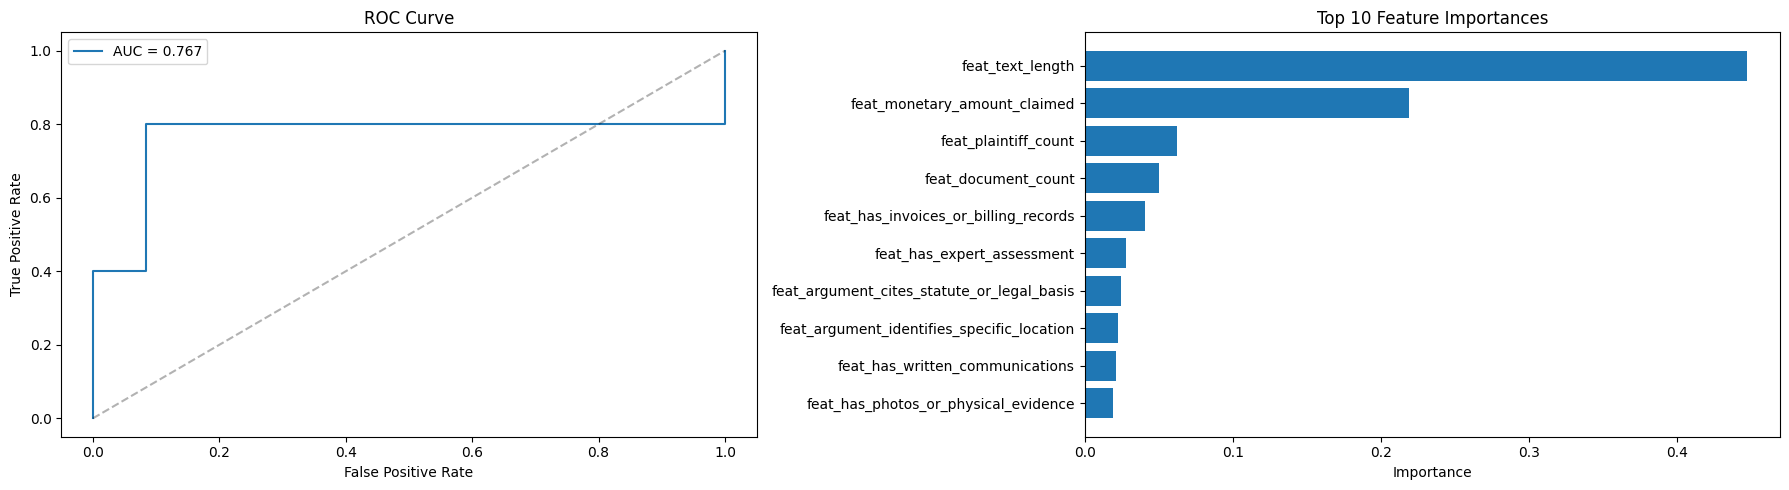

Saved figure → /Users/ernesto/Desktop/MLOPS-Project/litigation-outcome-pipeline/notebooks/eval_plots.png


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Top feature importances
imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
axes[1].barh(imp.index, imp.values)
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
fig_path = REPO_ROOT / 'notebooks' / 'eval_plots.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved figure → {fig_path}')

## MLflow tracking

Logs this training run to MLflow so we can compare future runs side-by-side and reload the model later.

### What gets logged
- **params** — model hyperparameters + dataset shape (so the run is reproducible)
- **metrics** — train/test accuracy, ROC AUC, per-class precision/recall/F1, and the train→test gap (overfit diagnostic)
- **model** — the trained sklearn classifier itself, loadable later via `mlflow.sklearn.load_model(...)`
- **artifacts** — the dataset CSV and the eval figure, attached to the run

### Where it goes
By default this writes to a local `mlruns/` directory in the repo root (no server needed). To use the team's remote MLflow server instead, set the env var **before** running this cell:

```bash
export MLFLOW_TRACKING_URI=http://<server-ip>:5000
```

### Viewing results
After the cell runs, launch the MLflow UI from the repo root:

```bash
mlflow ui --backend-store-uri file:./mlruns
# open http://localhost:5000
```

You'll see one row per run with all params and metrics, the trained model artifact, the dataset, and the saved figure.

In [81]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import precision_recall_fscore_support

# Local file-based tracking unless the env var points to a remote server
tracking_uri = os.environ.get('MLFLOW_TRACKING_URI', f'file:{REPO_ROOT}/mlruns')
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment('litigation-classifier-smoke')

with mlflow.start_run(run_name='ernesto_ML_notebook') as run:
    # --- Params (reproducibility): hyperparameters + dataset shape
    mlflow.log_params(params)
    mlflow.log_param('n_features', X.shape[1])
    mlflow.log_param('n_train',    len(X_train))
    mlflow.log_param('n_test',     len(X_test))
    mlflow.log_param('class_balance_train', f'{(y_train==1).mean():.2f}')

    # --- Metrics: high-level + per-class + overfit diagnostic
    mlflow.log_metric('train_accuracy', train_acc)
    mlflow.log_metric('test_accuracy',  test_acc)
    mlflow.log_metric('test_roc_auc',   auc)
    mlflow.log_metric('overfit_gap',    train_acc - test_acc)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average=None, labels=[0, 1], zero_division=0
    )
    mlflow.log_metric('precision_not_win', prec[0])
    mlflow.log_metric('recall_not_win',    rec[0])
    mlflow.log_metric('f1_not_win',        f1[0])
    mlflow.log_metric('precision_win',     prec[1])
    mlflow.log_metric('recall_win',        rec[1])
    mlflow.log_metric('f1_win',            f1[1])

    # --- Trained model artifact (loadable later)
    mlflow.sklearn.log_model(clf, name='classifier')

    # --- Supporting artifacts so the run is fully self-contained
    mlflow.log_artifact(str(DATASET_CSV))
    mlflow.log_artifact(str(fig_path))

    print(f'Run ID:       {run.info.run_id}')
    print(f'Tracking URI: {tracking_uri}')
    print()
    print('To view in the MLflow UI:')
    print(f"  mlflow ui --backend-store-uri '{tracking_uri}'")

2026/04/25 17:30:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run ID:       c66e4c5440df4fa88bce8b2a0042151f
Tracking URI: file:/Users/ernesto/Desktop/MLOPS-Project/litigation-outcome-pipeline/mlruns

To view in the MLflow UI:
  mlflow ui --backend-store-uri 'file:/Users/ernesto/Desktop/MLOPS-Project/litigation-outcome-pipeline/mlruns'


## Notes

Smoke test confirmed: **train 1.00 / test 0.77** is classic overfitting (model memorized 68 training rows). To get a real model:
1. Run feature extraction on the remaining ~720 labeled cases
2. Re-run this notebook — MLflow will log a new run, comparable side-by-side to this one
3. When metrics look good, register the model in the MLflow Model Registry and promote it to Production so the FastAPI service picks it up